# Random Forest Classification

In this notebook, I will build a Random Forest classifier to classify DNA splice-junction sequences using the 3-mer features created in the previous notebook.

I will:
- load the prepared k-mer features,
- use the same train-test split as the SVM,
- train a Random Forest model,
- evaluate its performance,
- tune the model with a small controlled parameter search,
- and select the final Random Forest model.

The Random Forest results will later be compared with the SVM model.

In [1]:
from pathlib import Path
import pandas as pd

FEATURE_PATH = Path("../data/processed")

X = pd.read_csv(FEATURE_PATH / "kmer_features.csv")
y = pd.read_csv(FEATURE_PATH / "kmer_target.csv").squeeze()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3178, 97)
Target shape: (3178,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (2542, 97)
Testing shape: (636, 97)


In [ ]:
#Train Baseline Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [4]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated:", len(y_pred_rf))

Random Forest predictions generated: 636


In [5]:
#Evaluate Random Forest
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6840

Classification Report:
              precision    recall  f1-score   support

          EI       0.75      0.51      0.61       152
          IE       0.76      0.42      0.54       153
           N       0.65      0.89      0.75       331

    accuracy                           0.68       636
   macro avg       0.72      0.61      0.63       636
weighted avg       0.70      0.68      0.67       636



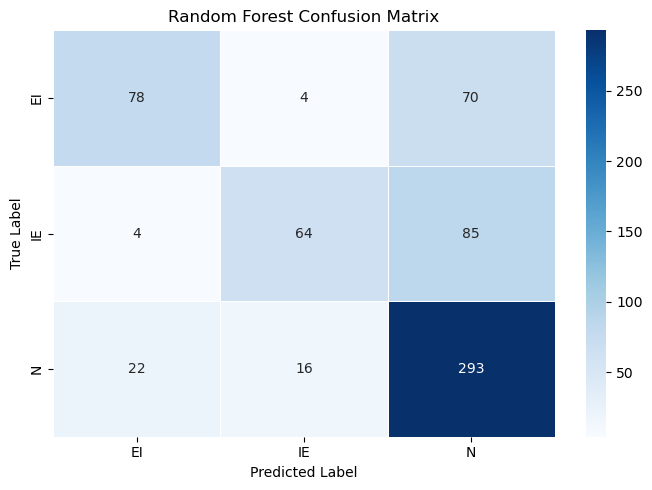

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["EI", "IE", "N"],
    yticklabels=["EI", "IE", "N"],
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters:", grid_search_rf.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search_rf.best_score_:.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.6849


In [11]:
#Create Tuned Random Forest
best_rf = grid_search_rf.best_estimator_

y_pred_tuned_rf = best_rf.predict(X_test)

print("Tuned Random Forest predictions generated:", len(y_pred_tuned_rf))

Tuned Random Forest predictions generated: 636


In [12]:
#Evaluate Tuned Random Forest
from sklearn.metrics import accuracy_score, classification_report

tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest Accuracy: {tuned_rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

Tuned Random Forest Accuracy: 0.6792

Classification Report:
              precision    recall  f1-score   support

          EI       0.75      0.49      0.60       152
          IE       0.75      0.41      0.53       153
           N       0.65      0.89      0.75       331

    accuracy                           0.68       636
   macro avg       0.72      0.60      0.63       636
weighted avg       0.70      0.68      0.66       636



In [14]:
print(f"Baseline Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Tuned Random Forest Accuracy:    {tuned_rf_accuracy:.4f}")

Baseline Random Forest Accuracy: 0.6840
Tuned Random Forest Accuracy:    0.6792
